# Task 1 - Data Cleaning



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
# Missing values fill
df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Create new column
df['Year'] = df['Order Date'].dt.year

df.head()

/tmp/ipykernel_5779/1356265742.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year
0,1,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017.0
1,2,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017.0
2,3,CA-2017-138688,2017-12-06,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017.0
3,4,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016.0
4,5,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016.0


In [ ]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.to_csv("cleaned_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 2: Exploratory Data Analysis [EDA]

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year
0,1,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017.0
1,2,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017.0
2,3,CA-2017-138688,2017-12-06,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017.0
3,4,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016.0
4,5,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016.0


In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Year
count,9800.000000,9800.000000,9800.000000,3959.000000
mean,4900.500000,55295.655714,230.769059,2016.728467
std,2829.160653,32035.893637,626.651875,1.119118
min,1.000000,1040.000000,0.444000,2015.000000
25%,2450.750000,23223.000000,17.248000,2016.000000
50%,4900.500000,59253.500000,54.490000,2017.000000
75%,7350.250000,90008.000000,210.605000,2018.000000
max,9800.000000,99301.000000,22638.480000,2018.000000


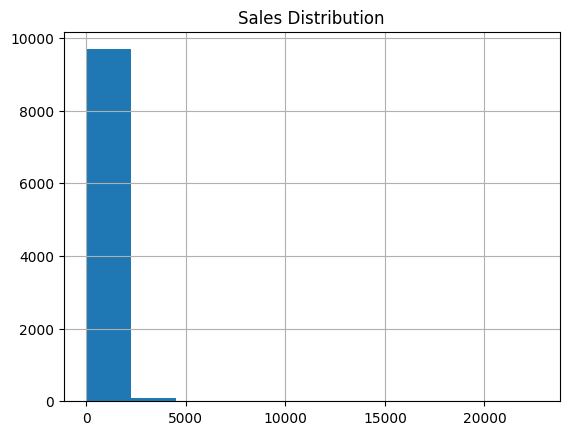

In [ ]:
import matplotlib.pyplot as plt

df['Sales'].hist()
plt.title("Sales Distribution")
plt.show()

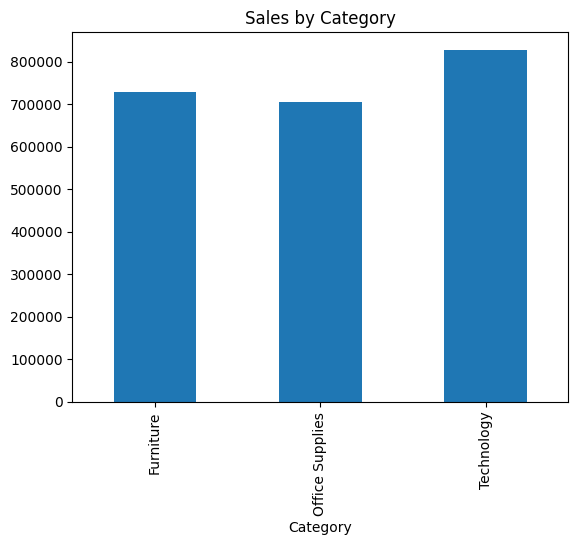

In [ ]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

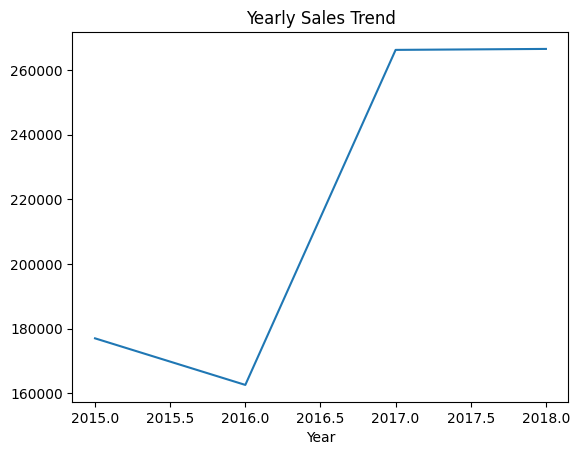

In [ ]:
df.groupby('Year')['Sales'].sum().plot(kind='line')
plt.title("Yearly Sales Trend")
plt.show()

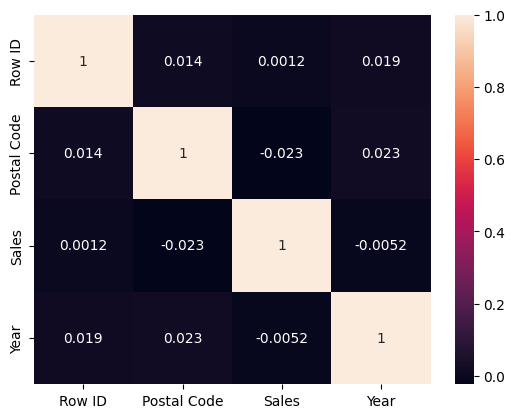

In [ ]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
plt.savefig("histogram.png")

<Figure size 640x480 with 0 Axes>

# Task 3: Deep-Dive Analysis & Dashboard

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827000003


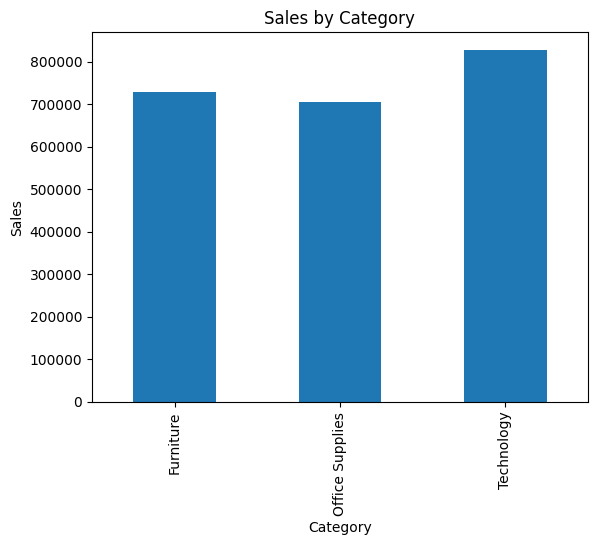

In [ ]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

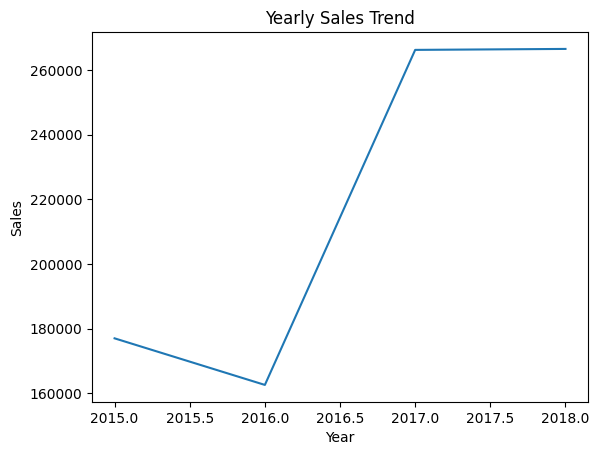

In [ ]:
df.groupby('Year')['Sales'].sum().plot(kind='line')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

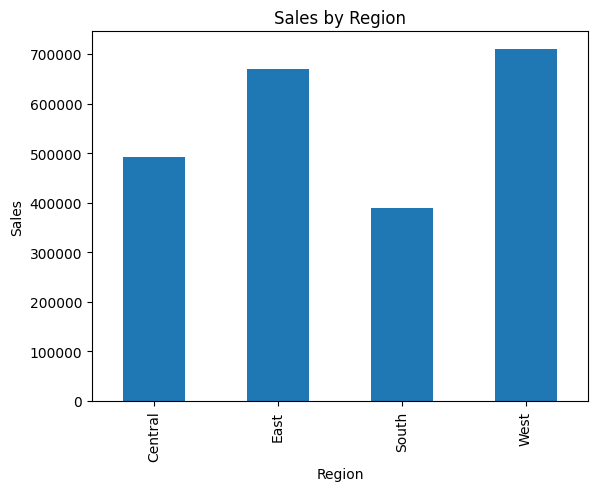

In [ ]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# Task: 4  Data Storytelling & Statistical Validation

In [ ]:
# Year-wise Sales
year_sales = df.groupby('Year')['Sales'].sum()
print("Year-wise Sales:\n", year_sales)

# Category-wise Sales
category_sales = df.groupby('Category')['Sales'].sum()
print("\nCategory-wise Sales:\n", category_sales)

Year-wise Sales:
 Year
2015.0    176986.5857
2016.0    162568.8627
2017.0    266254.6009
2018.0    266553.0743
Name: Sales, dtype: float64

Category-wise Sales:
 Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


In [ ]:
df.groupby('Year')['Sales'].sum()

,Sales
Year,
2015.0,176986.5857
2016.0,162568.8627
2017.0,266254.6009
2018.0,266553.0743


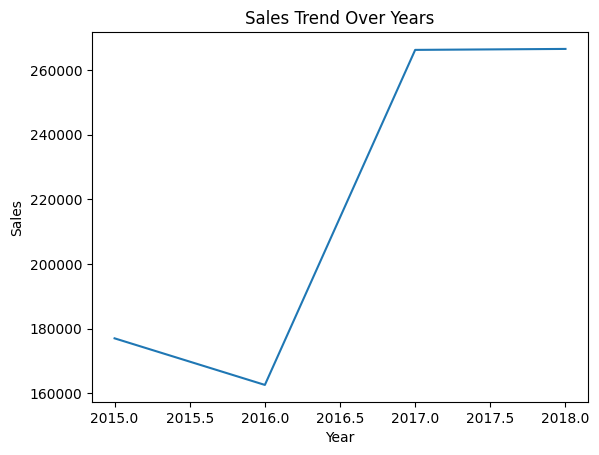

In [ ]:
import matplotlib.pyplot as plt

year_sales.plot(kind='line')
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

# Task 4: Data Storytelling & Analysis

In this task, I created a data story using the analysis performed in previous tasks.

From the analysis, I observed that sales are increasing over time, which indicates business growth. I also found that some categories contribute more to overall revenue than others.

This analysis helps in understanding business performance and supports better decision-making.

Hypothesis:
Sales in recent years are higher than previous years.

Result:
Sales have increased over time.

Conclusion:
- Sales are increasing year by year
- Category performance varies
- Overall business growth is positive